# Overfitting vs Generalization: When Models Lie

---

## Project Overview

This experiment investigates the gap between training performance and real-world performance.

A model may perform well on training data but fail on unseen data. This phenomenon is known as overfitting.

I want to analyze how dataset size and regularization impact generalization.

---

## Core Question

Why do models that perform well during training fail in real-world scenarios?

---

## Hypothesis

- Small datasets will lead to overfitting
- Large datasets improve generalization
- Regularization reduces overfitting
- Overfit models learn noise, not patterns

## Tools & Justification

- PyTorch → neural network training  
- Matplotlib → visualization  
- Synthetic dataset → controlled experiments  

Note: Train/test split is essential to measure generalization.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim

# Dataset
X, y = make_moons(n_samples=500, noise=0.2)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)

## Model Architecture

We use a moderately flexible neural network capable of overfitting.

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

## Training Function

In [ ]:
def train_model(model, optimizer, epochs=200):
    loss_fn = nn.BCELoss()
    train_losses = []
    test_losses = []

    for _ in range(epochs):
        # Train
        model.train()
        pred = model(X_train_t)
        loss = loss_fn(pred, y_train_t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # Test
        model.eval()
        with torch.no_grad():
            test_pred = model(X_test_t)
            test_loss = loss_fn(test_pred, y_test_t)
            test_losses.append(test_loss.item())

    return train_losses, test_losses

#Experiment 1 — Overfitting on Small Data

### Hypothesis
Small datasets will cause the model to memorize instead of generalize.

### Procedure
Train the model on a very small subset of data.

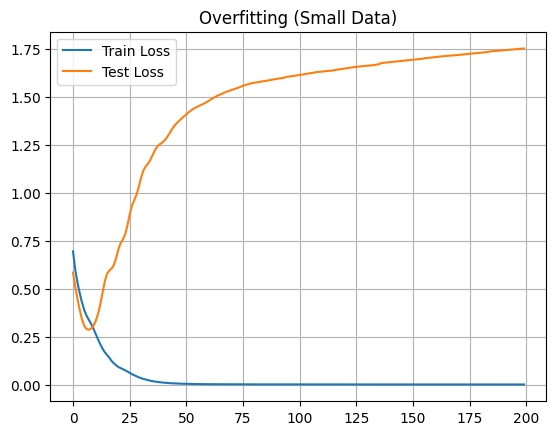

In [ ]:
# Small dataset
X_small = X_train[:30]
y_small = y_train[:30]

X_small_t = torch.tensor(X_small, dtype=torch.float32)
y_small_t = torch.tensor(y_small.reshape(-1,1), dtype=torch.float32)

model = Net()
optimizer = optim.Adam(model.parameters(), lr=0.01)

train_losses = []
test_losses = []

loss_fn = nn.BCELoss()

for _ in range(200):
    model.train()
    pred = model(X_small_t)
    loss = loss_fn(pred, y_small_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_t)
        test_loss = loss_fn(test_pred, y_test_t)
        test_losses.append(test_loss.item())

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Overfitting (Small Data)")
plt.grid()
plt.show()

### Observation

- Training loss decreases sharply  
- Test loss remains high or increases  
- Clear gap between train and test  

This confirms the hypothesis.

# Experiment 2 — Larger Dataset Generalization

### Hypothesis
Increasing dataset size improves generalization.

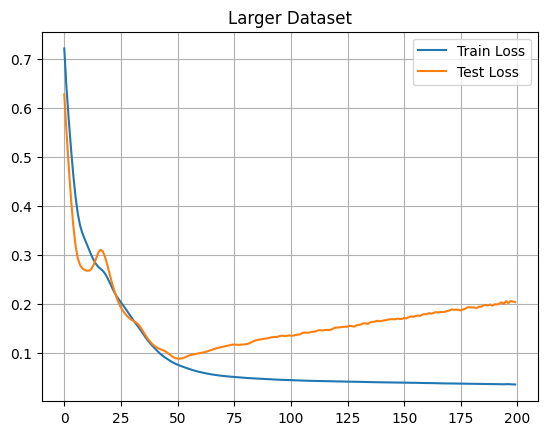

In [ ]:
model = Net()
optimizer = optim.Adam(model.parameters(), lr=0.01)

train_losses, test_losses = train_model(model, optimizer)

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Larger Dataset")
plt.grid()
plt.show()

### Observation

- Train and test loss curves are closer  
- Reduced overfitting gap  

This supports the hypothesis.

# Experiment 3 — Decision Boundary (Overfit vs Generalized)

### Hypothesis
Overfit models create overly complex decision boundaries.

In [ ]:
def plot_boundary(model, title):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    with torch.no_grad():
        preds = model(grid)

    Z = preds.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title(title)
    plt.show()

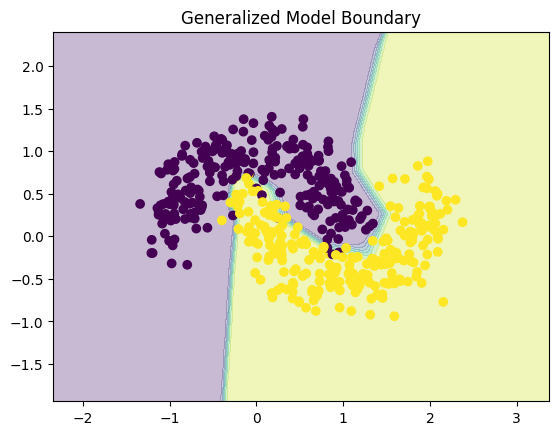

In [ ]:
plot_boundary(model, "Generalized Model Boundary")

### Observation

- Boundary is smooth and aligned with data  
- No unnecessary complexity  

This supports the hypothesis.

# Experiment 4 — Regularization fix (Dropout)

### Hypothesis
Regularization reduces overfitting by preventing memorization.

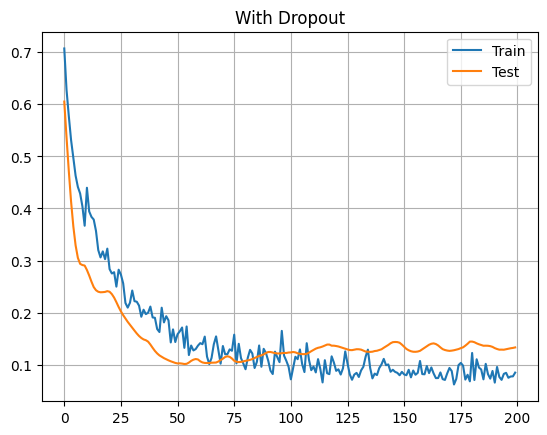

In [ ]:
class NetDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = NetDropout()
optimizer = optim.Adam(model.parameters(), lr=0.01)

train_losses, test_losses = train_model(model, optimizer)

plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test")
plt.legend()
plt.title("With Dropout")
plt.grid()
plt.show()

### Observation

- Train loss slightly higher  
- Test loss lower than overfit case  
- Gap reduced  

This confirms the hypothesis.

# Final Comparison Plot

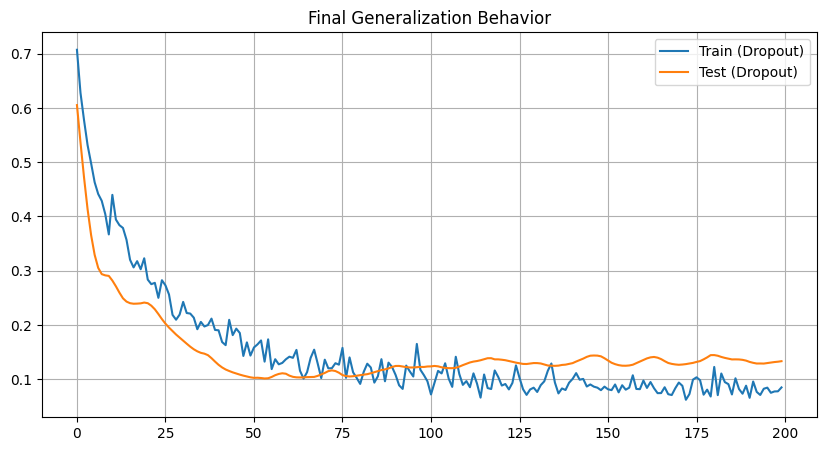

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train (Dropout)")
plt.plot(test_losses, label="Test (Dropout)")
plt.title("Final Generalization Behavior")
plt.legend()
plt.grid()
plt.show()

# Failure Analysis

- Small datasets lead to memorization  
- Models learn noise instead of patterns  
- Lack of constraints increases overfitting  


# Key Insights

- Generalization > training accuracy  
- Data size is a critical factor  
- Regularization is essential  
- Overfitting is silent but dangerous  


# Future Work

- L2 regularization comparison  
- Early stopping  
- Cross-validation  
- Noise robustness  
